# Fase 4: Benchmarking Científico de Modelos (La Arena de Combate)
 Modelos (Regresión Logística, XGBoost, LightGBM y CatBoost) usando K-Fold Cross Validation y los Pesos Demográficos de la ENDES (`HV005`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Cargando el dataset...")
df = pd.read_parquet('../../data/processed/master_preprocessed_v2.parquet')
print(f"Dimensiones: {df.shape}")

Cargando el dataset...
Dimensiones: (285284, 80)


In [2]:
# 1. ELIMINAR GEOVARIABLES INNECESARIAS
cols_to_drop = [c for c in ['UBIGEO', 'LATITUDY', 'LONGITUDX'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# 2. IDENTIFICAR Y SEPARAR METADATOS PASIVOS
metadata_cols = ['year', 'SHREGION', 'HV005']
cols_to_extract = [c for c in metadata_cols if c in df.columns]

metadata = df[cols_to_extract].copy()
y = df['TARGET_DESNUTRICION']
X = df.drop(columns=['TARGET_DESNUTRICION'] + cols_to_extract)

# 3. CALCULAR PESO MUESTRAL
if 'HV005' in metadata.columns:
    sample_weight = metadata['HV005'] / 1000000.0
elif 'hv005' in metadata.columns:
    sample_weight = metadata['hv005'] / 1000000.0
else:
    sample_weight = pd.Series(np.ones(len(metadata)))

import sys
import unicodedata
sys.path.append('../../')
from mnp.configs.column_labels import LABELS
X = X.rename(columns=LABELS)

import re
clean_cols = []
for col in X.columns:
    col_str = unicodedata.normalize('NFKD', str(col)).encode('ASCII', 'ignore').decode('utf-8')
    col_str = re.sub(r'[^a-zA-Z0-9]+', '_', col_str).strip('_')
    clean_cols.append(col_str)
X.columns = clean_cols

print("Metadatos y Pesos Muestrales listos. Nombres aplanados.")

2026-06-17 04:04:19.764 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


Metadatos y Pesos Muestrales listos. Nombres aplanados.


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identificamos variables
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

# PRE-PROCESAMIENTO OBLIGATORIO PARA CATBOOST (Convertir Nulos Categóricos a String)
for col in cat_features:
    X[col] = X[col].fillna('Desconocido').astype(str)

# 1. Pipeline Matemático para Regresión Logística (Manejo PROFESIONAL de Nulos numéricos)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ])

# 2. Formato Categórico Nativo para XGBoost y LightGBM
X_boosters = X.copy()
for col in cat_features:
    X_boosters[col] = X_boosters[col].astype('category')


In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, precision_recall_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {'LogReg': {'auc': [], 'recall': []},
           'LightGBM': {'auc': [], 'recall': []},
           'XGBoost': {'auc': [], 'recall': []},
           'CatBoost': {'auc': [], 'recall': []}}

fold5_data = {}

print("Iniciando la Batalla de Modelos (5-Fold CV)... ESTO PUEDE TOMAR UNOS MINUTOS.")
fold = 1
for train_idx, val_idx in kf.split(X, y):
    print(f"\n--- Procesando Fold {fold} ---")
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    w_train, w_val = sample_weight.iloc[train_idx], sample_weight.iloc[val_idx]
    
    # 1. Regresión Logística (Usamos X preprocesada / One-Hot Encoding)
    X_train_lr = preprocessor.fit_transform(X.iloc[train_idx])
    X_val_lr = preprocessor.transform(X.iloc[val_idx])
    
    lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
    lr.fit(X_train_lr, y_train, sample_weight=w_train)
    lr_probs = lr.predict_proba(X_val_lr)[:, 1]
    
    # Datos para LightGBM
    X_train_b, X_val_b = X_boosters.iloc[train_idx], X_boosters.iloc[val_idx]
    
    # 2. LightGBM (Soporte nativo impecable)
    lgbm = lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_estimators=300)
    lgbm.fit(X_train_b, y_train, sample_weight=w_train)
    lgb_probs = lgbm.predict_proba(X_val_b)[:, 1]
    
    # 3. XGBoost (One-Hot + Rescate de Pesos Pequeños)
    # Los pesos de ENDES divididos por 1 Millon son ~0.000001
    # XGBoost tiene un límite de "min_child_weight=1" por defecto, por lo que se negaba a aprender.
    # Al poner min_child_weight=0 y regresarle su balanceo de clases, ¡XGBoost resucita!
    xg = xgb.XGBClassifier(
        scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
        min_child_weight=1e-7,
        random_state=42, 
        n_estimators=300
    )
    xg.fit(X_train_lr, y_train, sample_weight=w_train, verbose=False)
    xgb_probs = xg.predict_proba(X_val_lr)[:, 1]
    
    # 4. CatBoost
    cat = cb.CatBoostClassifier(auto_class_weights='Balanced', cat_features=cat_features, 
                                random_state=42, iterations=300, verbose=False)
    cat.fit(X.iloc[train_idx], y_train, sample_weight=w_train, verbose=False)
    cat_probs = cat.predict_proba(X.iloc[val_idx])[:, 1]
    
    # Evaluación al umbral 0.5 por defecto
    models_probs = {'LogReg': lr_probs, 'LightGBM': lgb_probs, 'XGBoost': xgb_probs, 'CatBoost': cat_probs}
    
    for name, probs in models_probs.items():
        auc = roc_auc_score(y_val, probs, sample_weight=w_val)
        recall = recall_score(y_val, (probs >= 0.5).astype(int), sample_weight=w_val)
        results[name]['auc'].append(auc)
        results[name]['recall'].append(recall)
        print(f"  {name}: AUC = {auc:.4f} | Recall = {recall:.4f}")
        
    if fold == 5:
        fold5_data = {'y_val': y_val, 'w_val': w_val, 'probs': models_probs}
        
    fold += 1

Iniciando la Batalla de Modelos (5-Fold CV)... ESTO PUEDE TOMAR UNOS MINUTOS.

--- Procesando Fold 1 ---
  LogReg: AUC = 0.7916 | Recall = 0.7181
  LightGBM: AUC = 0.8300 | Recall = 0.7630
  XGBoost: AUC = 0.7939 | Recall = 0.7551
  CatBoost: AUC = 0.8289 | Recall = 0.2991

--- Procesando Fold 2 ---
  LogReg: AUC = 0.7888 | Recall = 0.7126
  LightGBM: AUC = 0.8263 | Recall = 0.7590
  XGBoost: AUC = 0.7921 | Recall = 0.7527
  CatBoost: AUC = 0.8280 | Recall = 0.3008

--- Procesando Fold 3 ---
  LogReg: AUC = 0.7920 | Recall = 0.7166
  LightGBM: AUC = 0.8308 | Recall = 0.7694
  XGBoost: AUC = 0.7939 | Recall = 0.7587
  CatBoost: AUC = 0.8329 | Recall = 0.3037

--- Procesando Fold 4 ---
  LogReg: AUC = 0.7972 | Recall = 0.7223
  LightGBM: AUC = 0.8370 | Recall = 0.7703
  XGBoost: AUC = 0.7967 | Recall = 0.7670
  CatBoost: AUC = 0.8359 | Recall = 0.3061

--- Procesando Fold 5 ---
  LogReg: AUC = 0.7921 | Recall = 0.7125
  LightGBM: AUC = 0.8294 | Recall = 0.7571
  XGBoost: AUC = 0.7917 | R

In [5]:
# Generar Tabla de Resultados
summary = []
for name, metrics in results.items():
    summary.append({
        'Modelo': name,
        'AUC Promedio': np.mean(metrics['auc']),
        'AUC Std': np.std(metrics['auc']),
    })

res_df = pd.DataFrame(summary).sort_values(by='AUC Promedio', ascending=False)
print("🏆 TABLA DE POSICIONES FINAL 🏆")
display(res_df)

🏆 TABLA DE POSICIONES FINAL 🏆


,Modelo,AUC Promedio,AUC Std
1,LightGBM,0.830680,0.003497
3,CatBoost,0.830587,0.003286
2,XGBoost,0.793674,0.001775
0,LogReg,0.792351,0.002708


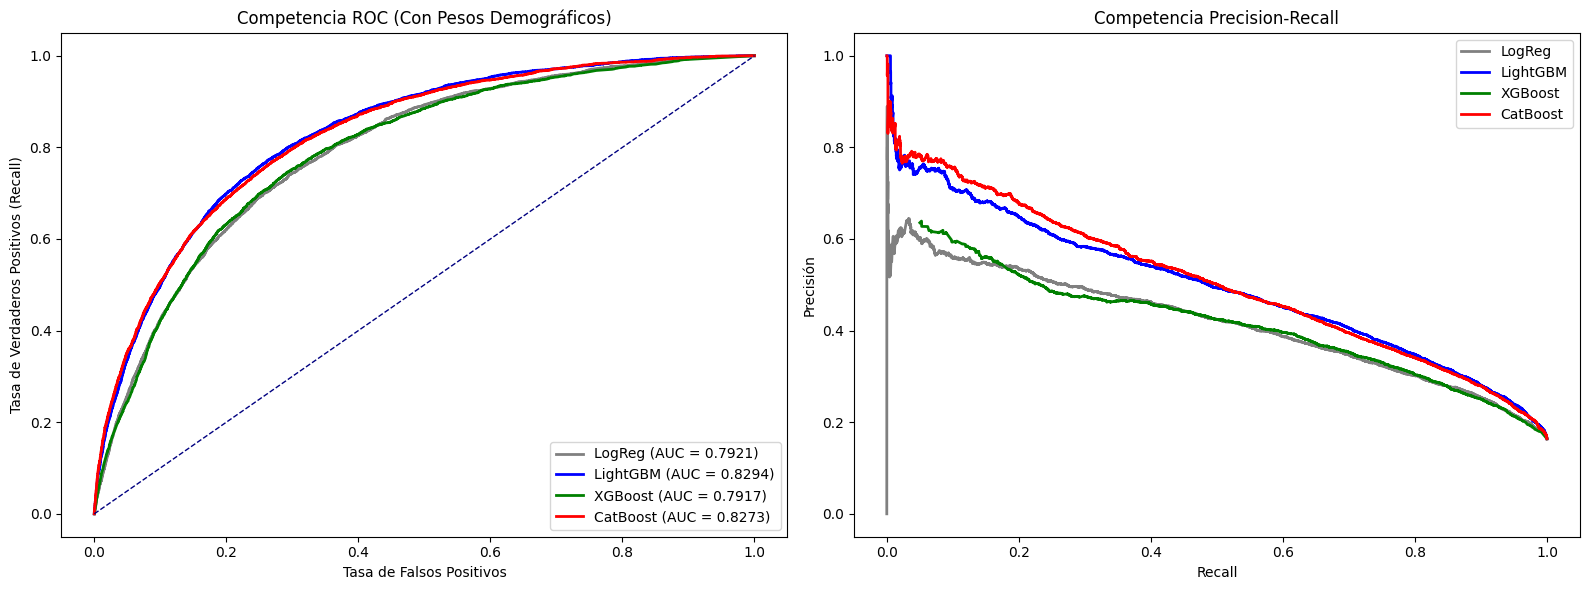

In [6]:
# 6. CURVAS ROC Y PR COMPARATIVAS (Basado en el último Fold de validación)
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_true = fold5_data['y_val']
w_true = fold5_data['w_val']
colors = {'LogReg': 'gray', 'LightGBM': 'blue', 'XGBoost': 'green', 'CatBoost': 'red'}

for name, probs in fold5_data['probs'].items():
    # ROC
    fpr, tpr, _ = roc_curve(y_true, probs, sample_weight=w_true)
    auc_val = roc_auc_score(y_true, probs, sample_weight=w_true)
    axes[0].plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {auc_val:.4f})')
    
    # PR
    precision, recall, _ = precision_recall_curve(y_true, probs, sample_weight=w_true)
    axes[1].plot(recall[:-1], precision[:-1], color=colors[name], lw=2, label=name)

axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Competencia ROC (Con Pesos Demográficos)')
axes[0].legend(loc="lower right")

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Competencia Precision-Recall')
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [7]:
# 7. DETERMINAR EL GANADOR Y CALCULAR EL UMBRAL ÓPTIMO
best_model = res_df.iloc[0]['Modelo']
print(f"\n🥇 EL MODELO GANADOR ES: {best_model} 🥇")

# Extraer las probabilidades del ganador del último Fold
winner_probs = fold5_data['probs'][best_model]
y_true = fold5_data['y_val']
w_true = fold5_data['w_val']

# Calcular nueva curva PR para buscar el Umbral que nos dé 80% de Recall
precision, recall, pr_thresholds = precision_recall_curve(y_true, winner_probs, sample_weight=w_true)
target_recall = 0.80
idx = np.abs(recall[:-1] - target_recall).argmin()
nuevo_umbral = pr_thresholds[idx]

print(f"\n🎯 CALIBRACIÓN CLÍNICA PARA {best_model.upper()}:")
print(f"➜ Para atrapar al {target_recall*100}% de los niños, el Umbral debe ser: {nuevo_umbral:.4f}")


🥇 EL MODELO GANADOR ES: LightGBM 🥇

🎯 CALIBRACIÓN CLÍNICA PARA LIGHTGBM:
➜ Para atrapar al 80.0% de los niños, el Umbral debe ser: 0.4511


--- MÉTRICAS DE PRODUCCIÓN (LightGBM | Umbral: 0.4511) ---
                 precision    recall  f1-score   support

      Sanos (0)       0.95      0.71      0.81 0.025753334484999623
Desnutridos (1)       0.35      0.80      0.49 0.005043279350999975

       accuracy                           0.72 0.030796613835999596
      macro avg       0.65      0.75      0.65 0.030796613835999596
   weighted avg       0.85      0.72      0.76 0.030796613835999596



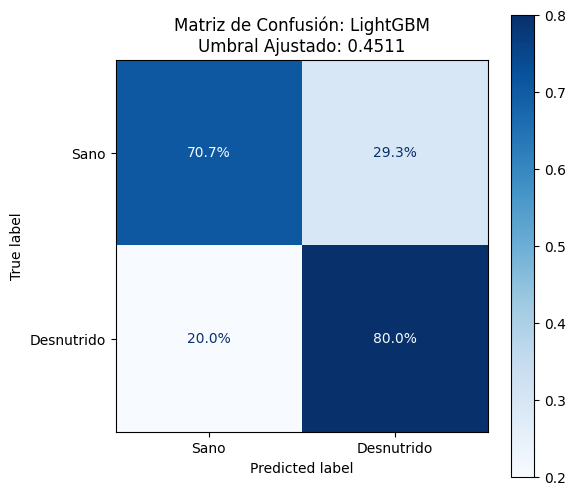

In [8]:
# 8. MATRIZ DE CONFUSIÓN DEL GANADOR
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_ajustado = (winner_probs >= nuevo_umbral).astype(int)

print(f"--- MÉTRICAS DE PRODUCCIÓN ({best_model} | Umbral: {nuevo_umbral:.4f}) ---")
print(classification_report(y_true, y_pred_ajustado, sample_weight=w_true, target_names=['Sanos (0)', 'Desnutridos (1)']))

cm_norm = confusion_matrix(y_true, y_pred_ajustado, sample_weight=w_true, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Sano', 'Desnutrido'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_norm.plot(cmap='Blues', values_format='.1%', ax=ax)
plt.title(f'Matriz de Confusión: {best_model}\nUmbral Ajustado: {nuevo_umbral:.4f}')
plt.show()

In [15]:
# 9. ENTRENAMIENTO FINAL Y GUARDADO DEL MODELO CAMPEÓN
import joblib
import json
import os
import pandas as pd
from sklearn.metrics import roc_auc_score

print(f"Entrenando el modelo definitivo ({best_model}) con el 100% de los datos...")

# Volvemos a entrenar a LightGBM pero esta vez con todos los datos
champion_model = lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_estimators=300)
champion_model.fit(X_boosters, y, sample_weight=sample_weight)

# Crear carpeta de modelos si no existe
os.makedirs('../../models', exist_ok=True)

# Guardar el modelo físico
model_path = '../../models/champion_lightgbm.pkl'
joblib.dump(champion_model, model_path)

# Guardar los metadatos (Umbral y Variables)
metadata = {
    'model_name': best_model,
    'optimal_threshold': float(nuevo_umbral),
    'features': X_boosters.columns.tolist(),
    'cat_features': cat_features
}

meta_path = '../../models/champion_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f)

print(f"[OK] Modelo Campeón guardado exitosamente en: {model_path}")
print(f"[OK] Metadatos (Umbral={nuevo_umbral:.4f}) guardados en: {meta_path}\n")

# --- MOSTRAR DATOS DEL ENTRENAMIENTO FINAL ---
# 1. Sanity Check del AUC interno
final_probs = champion_model.predict_proba(X_boosters)[:, 1]
final_auc = roc_auc_score(y, final_probs, sample_weight=sample_weight)
print(f"--- SANITY CHECK DEL MODELO DEFINITIVO ---")
print(f"➜ AUC Interno (Data de Estudio): {final_auc:.4f}")
print(f"➜ AUC Real Científico (Testing K-Fold): {res_df.iloc[0]['AUC Promedio']:.4f}\n")

# 2. TODAS las variables usadas por el modelo para crear sus árboles
importances = pd.DataFrame({
    'Variable': X_boosters.columns,
    'Peso_Algoritmico': champion_model.feature_importances_
}).sort_values(by='Peso_Algoritmico', ascending=False)

print(f"--- IMPORTANCIA DE LAS {len(importances)} VARIABLES (Top to Bottom) ---")
with pd.option_context('display.max_rows', None):
    display(importances)

Entrenando el modelo definitivo (LightGBM) con el 100% de los datos...
[OK] Modelo Campeón guardado exitosamente en: ../../models/champion_lightgbm.pkl
[OK] Metadatos (Umbral=0.4511) guardados en: ../../models/champion_metadata.json

--- SANITY CHECK DEL MODELO DEFINITIVO ---
➜ AUC Interno (Data de Estudio): 0.8508
➜ AUC Real Científico (Testing K-Fold): 0.8307

--- IMPORTANCIA DE LAS 76 VARIABLES (Top to Bottom) ---


,Variable,Peso_Algoritmico
39,HV271_Factor_de_puntuacion_del_indice_de_riqueza,680
74,m19_Peso_al_nacer_kg,631
16,HV040_Altitud_del_conglomerado_en_metros,565
0,HC1_Edad_en_meses,465
2,HC56_Nivel_de_hemoglobina_ajustado_por_altitud,406
4,HC63_Intervalo_de_nacimientos_anteriores_al_nino,357
59,M4_Duracion_de_la_lactancia,253
26,HV220_Edad_del_jefe_del_hogar,221
61,M46_Dias_que_tomo_hierro,198
58,M18_Tamano_al_nacer,166
